EXEMPLOS DE VIZUALIZAÇÕES

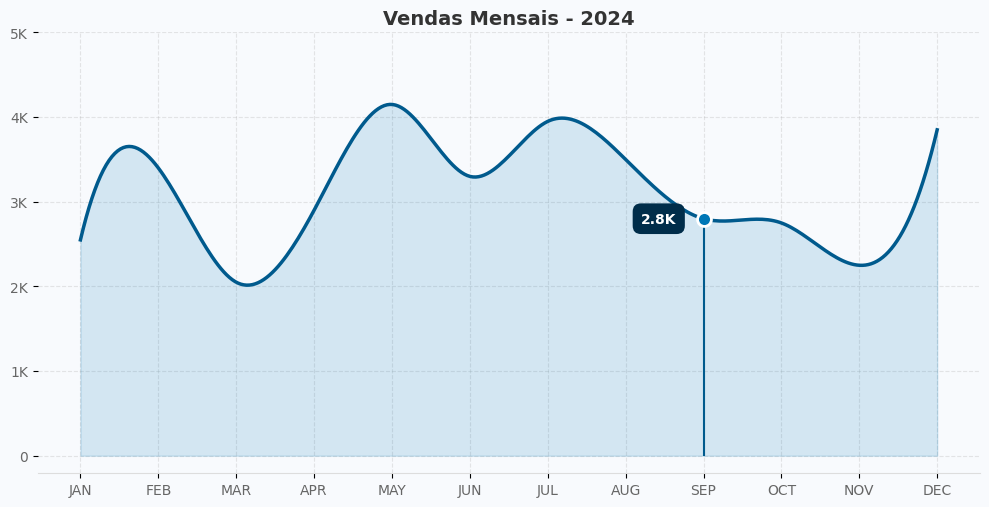

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# --- 1. CONFIGURAÇÃO DOS DADOS ---
meses = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
x = np.arange(len(meses))
y = np.array([2550, 3400, 2050, 2900, 4150, 3300, 3950, 3500, 2800, 2750, 2250, 3850])

# --- 2. SUAVIZAÇÃO DA CURVA (SPLINE) ---
# Criamos 300 pontos para que a linha pareça uma onda fluida
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_smooth)

# --- 3. CRIAÇÃO DO GRÁFICO ---
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#f8fafd')
ax.set_facecolor('#f8fafd') # Cor de fundo leve

# Linha principal e preenchimento
ax.plot(x_smooth, y_smooth, color='#005a8d', linewidth=2.5, zorder=3)
ax.fill_between(x_smooth, y_smooth, color='#0077b6', alpha=0.15, zorder=2)

# --- 4. ELEMENTOS DE DESTAQUE (SETEMBRO) ---
idx_sep = 8 # Índice de Setembro
x_val = x[idx_sep]
y_val = y[idx_sep]

# Linha vertical indicadora
ax.vlines(x_val, 0, y_val, color='#005a8d', linestyle='-', linewidth=1.5, zorder=4)

# Marcador (ponto azul com borda branca)
ax.plot(x_val, y_val, marker='o', markersize=10, markerfacecolor='#0077b6', 
        markeredgecolor='white', markeredgewidth=2, zorder=6)

# Caixa de texto (Tooltip "2.8K")
ax.annotate(f'{y_val/1000:.1f}K', 
            xy=(x_val, y_val), 
            xytext=(-45, 0), # Posição relativa à esquerda do ponto
            textcoords='offset points',
            color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', fc='#002d4a', ec='none'),
            va='center', zorder=7)

# --- 5. ESTILIZAÇÃO DOS EIXOS E GRID ---
ax.set_xticks(x)
ax.set_xticklabels(meses, color='#666', fontsize=10)
ax.set_yticks([0, 1000, 2000, 3000, 4000, 5000])
ax.set_yticklabels(['0', '1K', '2K', '3K', '4K', '5K'], color='#666', fontsize=10)

# Grade tracejada (estilo dash)
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

# Remover as bordas (spines) desnecessárias
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#ddd')

plt.tight_layout()
plt.title('Vendas Mensais - 2024', color='#333', fontsize=14, fontweight='bold')
plt.show()

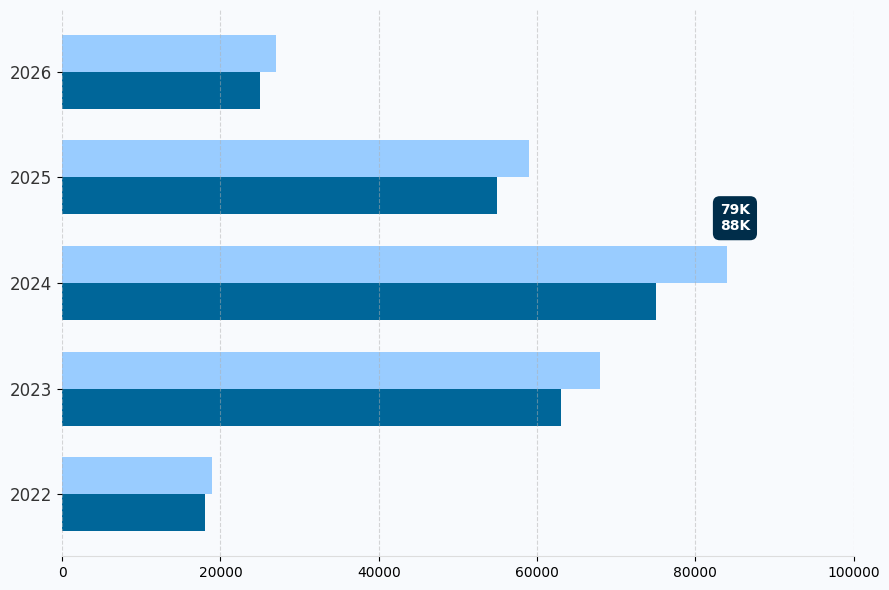

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURAÇÃO DOS DADOS ---
anos = ['2022', '2023', '2024', '2025', '2026']
setor_a = [18000, 63000, 75000, 55000, 25000] # Barra azul escura
setor_b = [19000, 68000, 84000, 59000, 27000] # Barra azul clara

# --- 2. POSICIONAMENTO ---
x = np.arange(len(anos))  # Posições base
largura = 0.35            # Largura de cada barra

fig, ax = plt.subplots(figsize=(9, 6), facecolor='#f8fafd')
ax.set_facecolor('#f8fafd')

# Criando as barras deslocadas (offset)
rects1 = ax.barh(x - largura/2, setor_a, largura, label='Setor A', color='#006699')
rects2 = ax.barh(x + largura/2, setor_b, largura, label='Setor B', color='#99ccff')

# --- 3. ESTILIZAÇÃO ---
ax.set_yticks(x)
ax.set_yticklabels(anos, fontsize=12, color='#333')
ax.set_xlim(0, 100000)

# Grade apenas no eixo X (tracejada)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)

# Remover bordas
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#ddd')

# Adicionar o Tooltip (exemplo para o ano de 2024)
ax.annotate('79K\n88K', xy=(80000, 2.2), xytext=(85000, 2.5),
            bbox=dict(boxstyle='round,pad=0.5', fc='#002d4a', ec='none'),
            color='white', fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

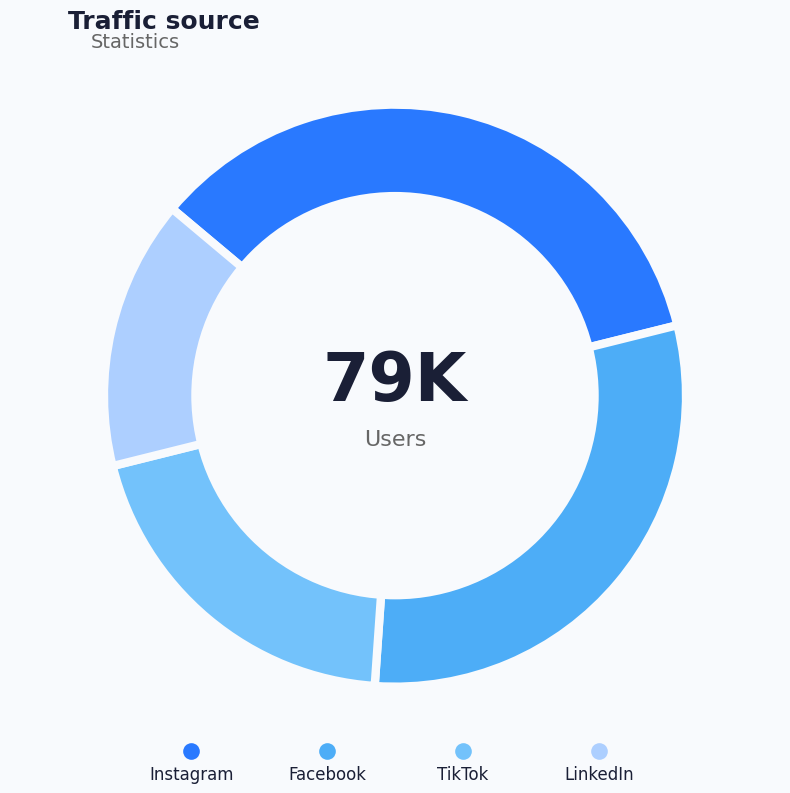

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURAÇÃO DOS DADOS E CORES ---
# Dados estimados baseados visualmente na imagem
fontes = ['Instagram', 'Facebook', 'TikTok', 'LinkedIn']
valores = [35, 30, 20, 15] # Porcentagens aproximadas

# Cores exatas do degradê azul (claro para escuro)
cores = ['#2979ff', '#4dadf7', '#73c2fb', '#adcfff'] # LinkedIn é o mais claro

# --- 2. CRIAÇÃO DO GRÁFICO ---
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#f8fafd')
ax.set_facecolor('#f8fafd') # Cor de fundo leve

# Desenhar o gráfico de pizza (donut base)
# O 'wedgeprops' com linewidth e edgecolor cria o espaçamento branco
fatias, textos = ax.pie(
    valores, 
    colors=cores, 
    startangle=140, # Gira para posicionar os segmentos
    wedgeprops={'linewidth': 6, 'edgecolor': '#f8fafd', 'antialiased': True},
    counterclock=False # Inverter a direção dos segmentos
)

# --- 3. CRIAR O "DONUT" (CÍRCULO CENTRAL) ---
# Desenha um círculo branco no meio do gráfico de pizza
centro_circulo = plt.Circle((0,0), 0.70, fc='#f8fafd') # 0.70 define a espessura da rosca
ax.add_patch(centro_circulo)

# --- 4. ADICIONAR TEXTO CENTRAL ---
# Centralizar o "79K" e "Users"
ax.annotate('79K', xy=(0, 0.05), fontsize=48, fontweight='bold', color='#1a1f36', ha='center', va='center')
ax.annotate('Users', xy=(0, -0.15), fontsize=16, color='#666', ha='center', va='center')

# --- 5. LEGENDA PERSONALIZADA (Bolinhas) ---
# O Matplotlib não faz isso nativamente. Vamos desenhar as bolinhas manualmente.
y_pos_legenda = -1.30 # Posição vertical abaixo do gráfico

# Definir posições horizontais para alinhar o texto
x_posições = np.linspace(-0.7, 0.7, len(fontes))

for i, (fonte, cor) in enumerate(zip(fontes, cores)):
    # Desenhar a bolinha colorida
    ax.plot(x_posições[i], y_pos_legenda + 0.08, marker='o', markersize=12, 
            markerfacecolor=cor, markeredgecolor='none', linestyle='none', zorder=10)
    
    # Adicionar o texto (Nome da Rede Social)
    ax.text(x_posições[i], y_pos_legenda, fonte, ha='center', va='center', 
            fontsize=12, color='#1a1f36', fontweight='medium')

# --- 6. CONFIGURAÇÃO FINAL ---
# Ocultar eixos para um visual limpo de dashboard
ax.axis('equal') # Garante que o círculo seja redondo
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([])
plt.yticks([])

# Adicionar Títulos (opcional, igual à imagem)
ax.set_title('Traffic source', fontsize=18, fontweight='bold', color='#1a1f36', x=0.2, y=1.05)
fig.text(0.12, 0.94, 'Statistics', fontsize=14, color='#666')

plt.tight_layout()
plt.show()

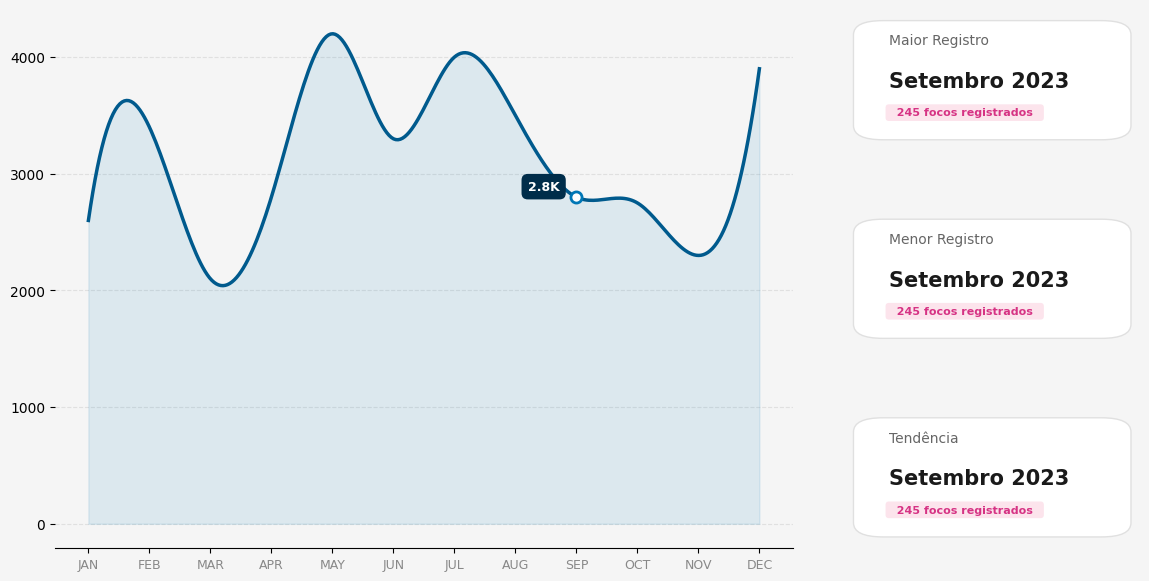

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np
from scipy.interpolate import make_interp_spline

# --- 1. DADOS ---
meses = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
x = np.arange(len(meses))
y = np.array([2600, 3400, 2100, 2800, 4200, 3300, 4000, 3500, 2800, 2750, 2300, 3900])

# Suavização da curva
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_smooth)

# --- 2. CONFIGURAÇÃO DO LAYOUT (GridSpec) ---
fig = plt.figure(figsize=(14, 7), facecolor='#f5f5f5')
gs = gridspec.GridSpec(3, 2, width_ratios=[2.5, 1], hspace=0.4, wspace=0.1)

# AX_GRAFICO: Ocupa todas as linhas da primeira coluna
ax_chart = fig.add_subplot(gs[:, 0])
ax_chart.set_facecolor('#f5f5f5')

# --- 3. DESENHANDO O GRÁFICO ---
ax_chart.plot(x_smooth, y_smooth, color='#005a8d', linewidth=2.5, zorder=3)
ax_chart.fill_between(x_smooth, y_smooth, color='#0077b6', alpha=0.1, zorder=2)

# Estilização do Gráfico
ax_chart.set_xticks(x)
ax_chart.set_xticklabels(meses, color='#888', fontsize=9)
ax_chart.grid(True, axis='y', linestyle='--', alpha=0.3)
for s in ['top', 'right', 'left']: ax_chart.spines[s].set_visible(False)

# Marcador e Tooltip (Setembro)
ax_chart.plot(8, 2800, marker='o', mfc='white', mec='#0077b6', mew=2, ms=8, zorder=5)
ax_chart.annotate('2.8K', xy=(8, 2800), xytext=(-35, 5), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', fc='#002d4a', ec='none'),
                 color='white', fontweight='bold', fontsize=9)

# --- 4. FUNÇÃO PARA CRIAR OS CARDS ---
def draw_card(ax_pos, titulo, valor, subtitulo):
    ax = fig.add_subplot(ax_pos)
    ax.set_facecolor('#f5f5f5')
    
    # Desenha o fundo branco arredondado (o "Card")
    card = FancyBboxPatch((0.05, 0.1), 0.9, 0.8, boxstyle="round,pad=0.02,rounding_size=0.1",
                          ec="#e0e0e0", fc="white", mutation_scale=1, zorder=1)
    ax.add_patch(card)
    
    # Textos do Card
    ax.text(0.15, 0.75, titulo, fontsize=10, color='#666', fontweight='medium', transform=ax.transAxes)
    ax.text(0.15, 0.45, valor, fontsize=15, color='#1a1a1a', fontweight='bold', transform=ax.transAxes)
    
    # Badge pequena (fundo rosa claro)
    ax.text(0.15, 0.25, f"  {subtitulo}  ", fontsize=8, color='#d63384', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='#fce4ec', ec='none'), transform=ax.transAxes)
    
    ax.axis('off')

# --- 5. ADICIONANDO OS CARDS LADO A LADO ---
draw_card(gs[0, 1], "Maior Registro", "Setembro 2023", "245 focos registrados")
draw_card(gs[1, 1], "Menor Registro", "Setembro 2023", "245 focos registrados")
draw_card(gs[2, 1], "Tendência", "Setembro 2023", "245 focos registrados")

plt.show()